# 02 — Preprocessing & Data Pipeline

This notebook builds the full data pipeline for training:

1. Stratified train / val / test split
2. Hard-negative weighting strategy
3. Augmentation pipeline (Albumentations)
4. PyTorch `Dataset` and `DataLoader`
5. Normalization statistics
6. Sanity checks on a batch

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

DATA_DIR  = Path('data')
IMG_DIR   = DATA_DIR / 'images'
MASK_DIR  = DATA_DIR / 'masks'
META_PATH = DATA_DIR / 'metadata.csv'
CLASSES   = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Training hyper-params (used downstream in notebook 03)
IMG_SIZE   = 224   # resize target
BATCH_SIZE = 32

/Users/eduardoyaginuma/Documents/Repositorios/insper/skin-cancer-images-segmentation/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load & Label

In [2]:
df = pd.read_csv(META_PATH)
df['label']        = df[CLASSES].idxmax(axis=1)
df['binary_label'] = (df['label'] == 'MEL').astype(int)
df['img_path']     = df['image'].apply(lambda x: str(IMG_DIR / f'{x}.jpg'))
df['mask_path']    = df['image'].apply(lambda x: str(MASK_DIR / f'{x}.png'))

print(f'Total samples: {len(df)}')
print(df['binary_label'].value_counts().rename({0: 'Non-MEL', 1: 'MEL'}))

Total samples: 10015
binary_label
Non-MEL    8902
MEL        1113
Name: count, dtype: int64


## 2. Stratified Train / Val / Test Split

Split: **70% train — 15% val — 15% test**, stratified on `binary_label`.

In [3]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['binary_label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['binary_label'], random_state=SEED
)

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    mel = split['binary_label'].sum()
    total = len(split)
    print(f'{name:5s}: {total:5d} samples  |  MEL={mel} ({mel/total*100:.1f}%)  |  non-MEL={total-mel}')

# Save splits for reproducibility
train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv',   index=False)
test_df.to_csv('test_split.csv',  index=False)
print('\nSplit CSVs saved.')

Train:  7010 samples  |  MEL=779 (11.1%)  |  non-MEL=6231
Val  :  1502 samples  |  MEL=167 (11.1%)  |  non-MEL=1335
Test :  1503 samples  |  MEL=167 (11.1%)  |  non-MEL=1336

Split CSVs saved.


## 3. Hard-Negative Weighting

Within the non-melanoma class, NV samples are the most visually similar to MEL.
We assign higher sampling weights to NV to act as hard negatives during training.

In [4]:
# Weight strategy:
#   MEL       → base_pos_weight  (handle imbalance)
#   NV        → hard_neg_weight  (hard negative, boosted)
#   all other → base_neg_weight

n_mel    = (train_df['binary_label'] == 1).sum()
n_nonmel = (train_df['binary_label'] == 0).sum()

base_pos_weight  = n_nonmel / n_mel   # ~8x
base_neg_weight  = 1.0
hard_neg_weight  = 2.0                # boost NV

def assign_sample_weight(row):
    if row['binary_label'] == 1:
        return base_pos_weight
    elif row['label'] == 'NV':
        return hard_neg_weight
    else:
        return base_neg_weight

train_df = train_df.copy()
train_df['sample_weight'] = train_df.apply(assign_sample_weight, axis=1)

print('Sample weight distribution:')
print(train_df.groupby('label')['sample_weight'].mean().round(2))

# Effective class frequency after weighting
weight_by_class = train_df.groupby('binary_label')['sample_weight'].sum()
print(f'\nWeighted non-MEL : MEL = {weight_by_class[0]:.0f} : {weight_by_class[1]:.0f}')
print(f'Effective ratio: {weight_by_class[0]/weight_by_class[1]:.2f}')

Sample weight distribution:
label
AKIEC    1.0
BCC      1.0
BKL      1.0
DF       1.0
MEL      8.0
NV       2.0
VASC     1.0
Name: sample_weight, dtype: float64

Weighted non-MEL : MEL = 10958 : 6231
Effective ratio: 1.76


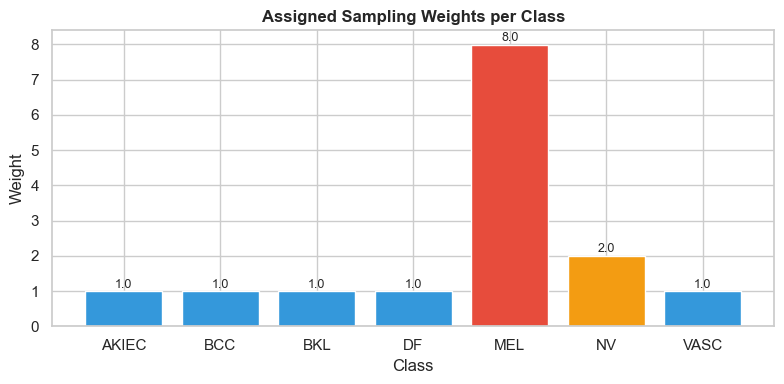

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
weight_summary = train_df.groupby('label')['sample_weight'].first()
colors = ['#e74c3c' if l == 'MEL' else '#f39c12' if l == 'NV' else '#3498db'
          for l in weight_summary.index]
ax.bar(weight_summary.index, weight_summary.values, color=colors)
ax.set_title('Assigned Sampling Weights per Class', fontweight='bold')
ax.set_ylabel('Weight')
ax.set_xlabel('Class')
for i, (cls, val) in enumerate(weight_summary.items()):
    ax.text(i, val + 0.1, f'{val:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('sample_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Augmentation Pipeline

**Training:** strong augmentation to improve robustness.  
**Validation / Test:** only resize + normalize (no stochastic augmentation).

In [6]:
# ImageNet normalization (used with pretrained EfficientNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.GaussNoise(p=0.3),
    A.CoarseDropout(max_holes=4, max_height=32, max_width=32, fill_value=0, p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print('Train transform:')
print(train_transform)
print('\nVal/Test transform:')
print(val_transform)

Train transform:
Compose([
  Resize(p=1.0, area_for_downscale=None, height=224, interpolation=1, mask_interpolation=0, width=224),
  HorizontalFlip(p=0.5),
  VerticalFlip(p=0.5),
  RandomRotate90(p=0.5),
  ShiftScaleRotate(p=0.5, shift_limit_x=(-0.05, 0.05), shift_limit_y=(-0.05, 0.05), scale_limit=(-0.09999999999999998, 0.10000000000000009), rotate_limit=(-15.0, 15.0), interpolation=1, border_mode=0, fill=0.0, fill_mask=0.0, rotate_method='largest_box', mask_interpolation=0),
  ColorJitter(p=0.5, brightness=(0.8, 1.2), contrast=(0.8, 1.2), hue=(-0.1, 0.1), saturation=(0.8, 1.2)),
  GaussNoise(p=0.3, mean_range=(0.0, 0.0), noise_scale_factor=1.0, per_channel=True, std_range=(0.2, 0.44)),
  CoarseDropout(p=0.3, fill=0.0, fill_mask=None, hole_height_range=(0.1, 0.2), hole_width_range=(0.1, 0.2), num_holes_range=(1, 2)),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
  ToTensorV2(p=1.0, transpose_mask=False),
], 

### Visualise Augmented Samples

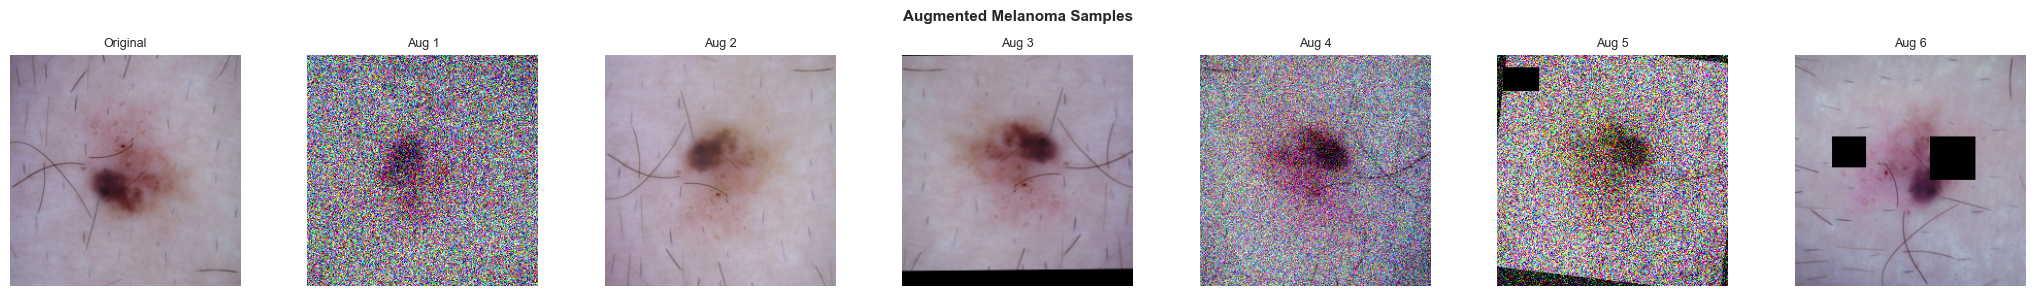

In [7]:
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = tensor.clone().permute(1, 2, 0).numpy()
    t = t * np.array(std) + np.array(mean)
    return np.clip(t, 0, 1)

sample_path = train_df[train_df['label'] == 'MEL']['img_path'].iloc[0]
orig_img = np.array(Image.open(sample_path).resize((IMG_SIZE, IMG_SIZE)))

N_AUGMENTED = 6
fig, axes = plt.subplots(1, N_AUGMENTED + 1, figsize=((N_AUGMENTED + 1) * 3, 3))
axes[0].imshow(orig_img)
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

for i in range(1, N_AUGMENTED + 1):
    aug = train_transform(image=orig_img)
    axes[i].imshow(denormalize(aug['image']))
    axes[i].set_title(f'Aug {i}', fontsize=9)
    axes[i].axis('off')

fig.suptitle('Augmented Melanoma Samples', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. PyTorch Dataset

In [8]:
class SkinLesionDataset(Dataset):
    """
    Binary skin lesion dataset (MEL=1, non-MEL=0).
    Optionally applies the lesion mask to zero-out background pixels.
    """
    def __init__(self, dataframe, transform=None, use_mask=False):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        self.use_mask  = use_mask

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = np.array(Image.open(row['img_path']).convert('RGB'))
        label = int(row['binary_label'])

        if self.use_mask:
            mask = np.array(Image.open(row['mask_path']).convert('L'))
            mask_bin = (mask > 127).astype(np.uint8)
            image = image * mask_bin[:, :, None]   # zero background

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, torch.tensor(label, dtype=torch.float32)

# Smoke test
ds = SkinLesionDataset(train_df, transform=train_transform)
img, lbl = ds[0]
print(f'Image shape: {img.shape}  Label: {lbl}')
print(f'Image dtype: {img.dtype}  Label dtype: {lbl.dtype}')

Image shape: torch.Size([3, 224, 224])  Label: 0.0
Image dtype: torch.float32  Label dtype: torch.float32


## 6. DataLoaders with WeightedRandomSampler

In [9]:
def make_loaders(train_df, val_df, test_df, batch_size=BATCH_SIZE, num_workers=0):
    train_ds = SkinLesionDataset(train_df, transform=train_transform)
    val_ds   = SkinLesionDataset(val_df,   transform=val_transform)
    test_ds  = SkinLesionDataset(test_df,  transform=val_transform)

    sample_weights = torch.tensor(train_df["sample_weight"].values, dtype=torch.float32)
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                              num_workers=num_workers, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=False)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")


Train batches: 220
Val   batches: 47
Test  batches: 47


## 7. Batch Sanity Check

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
MEL in batch: 10 / 32


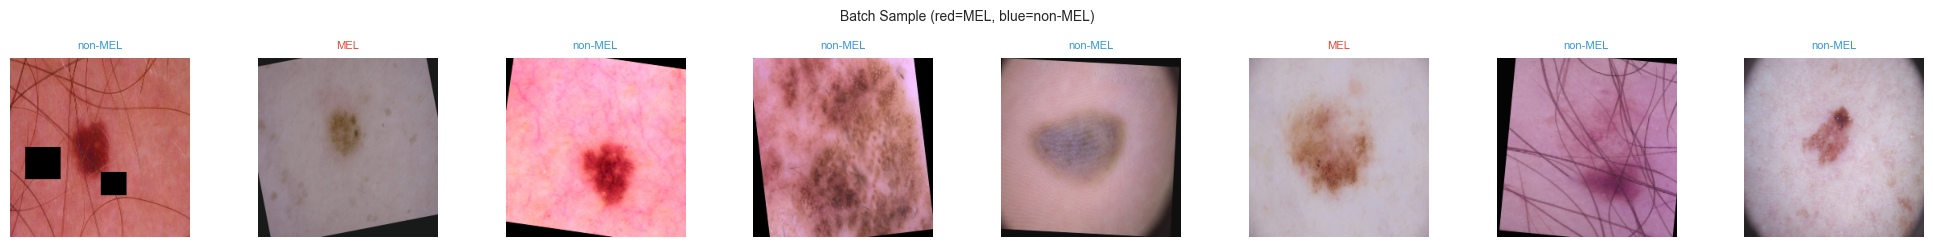

In [10]:
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = tensor.clone().permute(1, 2, 0).numpy()
    return np.clip(t * np.array(std) + np.array(mean), 0, 1)

# Rebuild a single-worker loader to avoid multiprocessing issues in notebooks
train_loader_local = DataLoader(
    train_loader.dataset,
    batch_size=train_loader.batch_size,
    sampler=train_loader.sampler,
    num_workers=0,
    pin_memory=False,
)

images, labels = next(iter(train_loader_local))
print(f'Batch images shape: {images.shape}')
print(f'Batch labels shape: {labels.shape}')
print(f'MEL in batch: {labels.sum().int().item()} / {len(labels)}')

N_SHOW = 8
fig, axes = plt.subplots(1, N_SHOW, figsize=(N_SHOW * 2.5, 2.5))
for i in range(N_SHOW):
    axes[i].imshow(denormalize(images[i]))
    color = '#e74c3c' if labels[i].item() == 1 else '#3498db'
    title = 'MEL' if labels[i].item() == 1 else 'non-MEL'
    axes[i].set_title(title, color=color, fontsize=8)
    axes[i].axis('off')

fig.suptitle('Batch Sample (red=MEL, blue=non-MEL)', fontsize=10)
plt.tight_layout()
plt.savefig('batch_sanity.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Verify Effective Class Balance After Sampling

In [11]:
n_mel_seen, n_total = 0, 0
for _, lbls in train_loader:
    n_mel_seen += lbls.sum().item()
    n_total    += len(lbls)

print(f'MEL proportion over one epoch (with sampler): {n_mel_seen/n_total*100:.1f}%')
print(f'Expected without sampler: ~{(train_df["binary_label"]==1).mean()*100:.1f}%')

MEL proportion over one epoch (with sampler): 36.4%
Expected without sampler: ~11.1%
